# Across animals multimodal analysis

In [1]:
import datajoint as dj
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import itertools
import pandas as pd
import os
from IPython.display import display, HTML
from scipy.stats import sem

# Style of plots
small_size=8
medium_size=20
large_size=40
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['pdf.fonttype'] =42
mpl.rcParams['axes.grid']=False
mpl.rcParams['axes.titlesize']=small_size
mpl.rcParams["figure.titlesize"] = medium_size
mpl.rcParams['axes.labelsize']=small_size
mpl.rcParams['xtick.labelsize']=small_size
mpl.rcParams['ytick.labelsize']=small_size
mpl.rcParams['legend.fontsize']=small_size


dj.config["enable_python_native_blobs"] = True
dj.config['database.host'] = 'database.eflab.org:3306'
dj.config['database.password'] = os.getenv('DJ_PASSWORD')


schemata = {'exp'   : 'lab_experiments',
            'stim'  : 'lab_stimuli',
            'beh'   : 'lab_behavior',
            'inter' : 'lab_interface',
            'rec'   :'lab_recordings',
            'mice' : 'lab_mice'}

# create a virtual module for every database schema that you are going to use
for schema, value in schemata.items():
    globals()[schema] = dj.create_virtual_module(schema, value, create_tables=True, create_schema=True)


[2026-05-25 12:05:06,110][INFO]: DataJoint 0.14.6 connected to eflab@database.eflab.org:3306


In [64]:
# complete the key
key_animals_sessions = {
    299: (107, 493),
    288: (184, 240),
    326: (57, 127),
    324: (47, 93),
    328: (105, 352),
}



,animal_id,session,auditory_perf,visual_perf,multi_perf,uni_perf
0,299,107,0.67,1.00,0.88,0.76
1,299,111,0.44,0.86,0.89,0.62
2,299,113,0.67,0.86,0.85,0.74
3,299,117,0.56,1.00,0.83,0.69
4,299,119,0.69,0.75,0.78,0.71
...,...,...,...,...,...,...
201,328,345,0.66,0.60,0.59,0.63
202,328,346,0.80,0.49,0.45,0.63
203,328,347,0.70,0.51,0.51,0.62
204,328,349,0.69,0.42,0.50,0.54


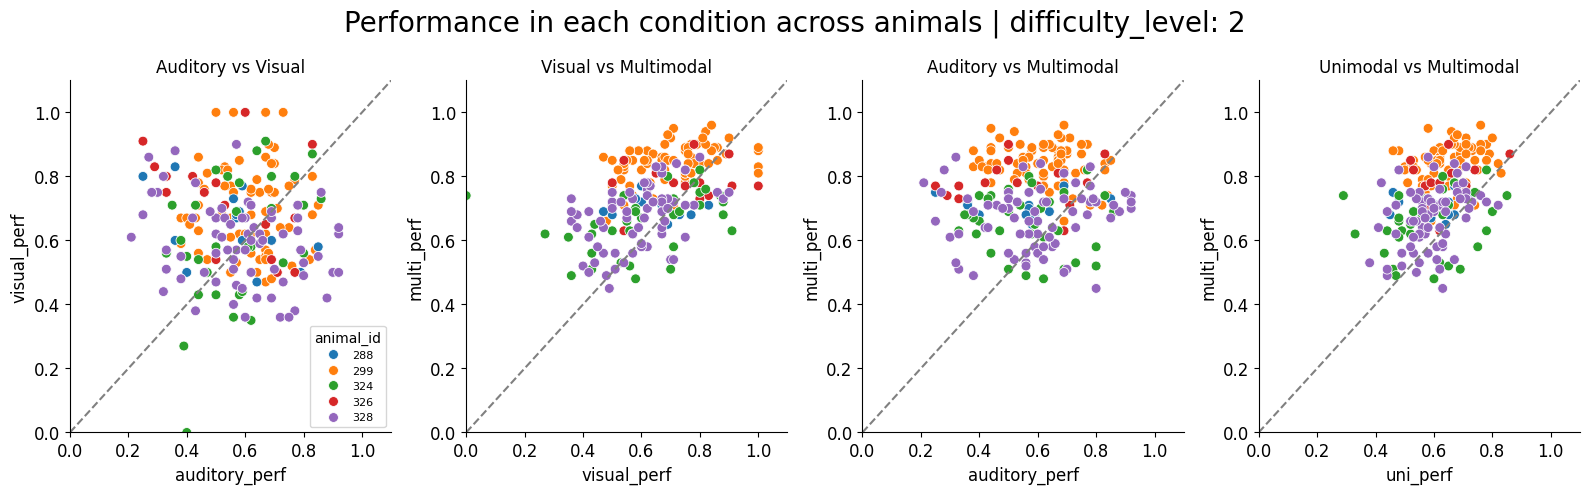

Skipped sessions per animal:
299 [142, 144, 146, 148, 150, 152, 154, 156, 158, 160, 169, 170, 172, 173, 185, 187, 188, 189, 190, 212, 216, 217, 218, 219, 221, 222, 223, 224, 225, 226, 229, 230, 233, 236, 237, 238, 239, 240, 241, 242, 243, 246, 247, 248, 249, 250, 254, 255, 256, 257, 258, 260, 261, 262, 264, 265, 267, 268, 269, 270, 272, 277, 278, 279, 280, 281, 283, 286, 288, 289, 290, 291, 293, 295, 297, 300, 301, 302, 303, 304, 305, 306, 307, 309, 310, 311, 316, 317, 318, 319, 320, 321, 348, 349, 350, 351, 353, 355, 356, 357, 358, 367, 368, 369, 371, 387, 391, 392, 394, 400, 401, 402, 404, 405, 406, 407, 409, 410, 413, 415, 416, 417, 418, 419, 421, 422, 425, 431, 432, 433, 434, 435, 436, 438, 439, 441, 442, 443, 445, 446, 447, 448, 449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 461, 462, 463, 469, 470, 471, 480, 484]
288 [208, 210, 212, 214, 216, 218, 220, 222, 225, 227, 237, 239, 240]
326 [102, 105, 107, 109, 111, 113, 115, 116, 118, 120, 121, 123, 125, 127]
324 []
328 [167, 169,

In [66]:
perf_all_animals = []
all_skipped = {}


# LOOP OVER ANIMALS
for animal_id, (from_session, to_session) in key_animals_sessions.items():

    restr = exp.Session() & {'animal_id': animal_id}
    valid_sessions = (restr - exp.Session.Excluded).fetch('session')

    perf_per_condition = []
    skipped_sessions = []

    for session in range(from_session, to_session + 1):

        if session not in valid_sessions:
            continue

        key = {'animal_id': animal_id, 'session': session}

        difficulty = (exp.Condition.MatchPort() * exp.Trial()).proj('difficulty')

        difficulty_level = 2

        # =========================
        # AUDITORY
        # =========================
        auditory_stateonset = (
            stim.StimCondition.Trial *
            (stim.Panda.Object).proj('obj_mag') *
            exp.Trial.StateOnset *
            difficulty *
            (stim.Tones).proj('tone_volume')
            & 'tone_volume > 0'
            & key
            & f'difficulty = {difficulty_level}'
            & 'state in ("Reward", "Punish")'
        ).fetch(format='frame').reset_index()

        auditory_stateonset['obj_mag'] = pd.to_numeric(auditory_stateonset['obj_mag'], errors='coerce')
        auditory_stateonset = auditory_stateonset[auditory_stateonset['obj_mag'] == 0]

        # =========================
        # VISUAL
        # =========================
        visual_stateonset = (
            stim.StimCondition.Trial *
            (stim.Panda.Object).proj('obj_mag') *
            exp.Trial.StateOnset *
            difficulty *
            (stim.Tones).proj('tone_volume')
            & 'tone_volume = 0'
            & key
            & f'difficulty = {difficulty_level}'
            & 'state in ("Reward", "Punish")'
        ).fetch(format='frame').reset_index()

        visual_stateonset['obj_mag'] = pd.to_numeric(visual_stateonset['obj_mag'], errors='coerce')
        visual_stateonset = visual_stateonset[visual_stateonset['obj_mag'] > 0]

        # =========================
        # MULTIMODAL
        # =========================
        multi_stateonset = (
            stim.StimCondition.Trial *
            (stim.Panda.Object).proj('obj_mag') *
            exp.Trial.StateOnset *
            difficulty *
            (stim.Tones).proj('tone_volume')
            & 'tone_volume > 0'
            & key
            & f'difficulty = {difficulty_level}'
            & 'state in ("Reward", "Punish")'
        ).fetch(format='frame').reset_index()

        multi_stateonset['obj_mag'] = pd.to_numeric(multi_stateonset['obj_mag'], errors='coerce')
        multi_stateonset = multi_stateonset[multi_stateonset['obj_mag'] > 0]

        # =========================
        # UNIMODAL (mixed single-modality trials)
        # =========================
        unimodal_stateonset = (
            stim.StimCondition.Trial *
            (stim.Panda.Object).proj('obj_mag') *
            exp.Trial.StateOnset *
            difficulty *
            (stim.Tones).proj('tone_volume')
            & key
            & f'difficulty = {difficulty_level}'
            & 'state in ("Reward", "Punish")'
        ).fetch(format='frame').reset_index()

        unimodal_stateonset['obj_mag'] = pd.to_numeric(unimodal_stateonset['obj_mag'], errors='coerce')
        unimodal_stateonset['tone_volume'] = pd.to_numeric(unimodal_stateonset['tone_volume'], errors='coerce')

        unimodal_stateonset = unimodal_stateonset[
            (
                (unimodal_stateonset['obj_mag'] > 0) &
                (unimodal_stateonset['tone_volume'] == 0)
            )
            |
            (
                (unimodal_stateonset['obj_mag'] == 0) &
                (unimodal_stateonset['tone_volume'] > 0)
            )
        ]

        # =========================
        # SKIP IF MISSING MODALITIES
        # =========================
        if (
            len(auditory_stateonset) == 0 or
            len(visual_stateonset) == 0 or
            len(multi_stateonset) == 0
        ):
            skipped_sessions.append(session)
            continue

        # =========================
        # PERFORMANCE
        # =========================
        perf_per_condition.append({
            'animal_id': animal_id,
            'session': session,
            'auditory_perf': round((auditory_stateonset['state'] == 'Reward').mean(), 2),
            'visual_perf': round((visual_stateonset['state'] == 'Reward').mean(), 2),
            'multi_perf': round((multi_stateonset['state'] == 'Reward').mean(), 2),
            'uni_perf': round((unimodal_stateonset['state'] == 'Reward').mean(), 2),
        })

    # =========================
    # STORE PER ANIMAL
    # =========================
    perf_df = pd.DataFrame(perf_per_condition)

    if len(perf_df) > 0:
        perf_df['session'] = perf_df['session'].astype(str)
        perf_all_animals.append(perf_df)

    all_skipped[animal_id] = skipped_sessions


# =========================
# FINAL DATAFRAME
# =========================
all_results = pd.concat(perf_all_animals, ignore_index=True)
all_results['session'] = all_results['session'].astype(str)

display(all_results)


# =========================
# PLOTTING (ALL ANIMALS TOGETHER)
# =========================
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

palette = sns.color_palette("tab10", n_colors=5)

# -------------------------
# 1. Auditory vs Visual
# -------------------------
sns.scatterplot(
    data=all_results,
    x='auditory_perf',
    y='visual_perf',
    hue='animal_id',
    palette=palette,
    ax=axes[0],
    s=50
)
axes[0].set_title('Auditory vs Visual', fontsize=12)
axes[0].set_xlabel('auditory_perf', fontsize=12)
axes[0].set_ylabel('visual_perf', fontsize=12)
axes[0].tick_params(axis='both', labelsize=12)
axes[0].set_xlim(0, 1.1)
axes[0].set_ylim(0, 1.1)
axes[0].axline((0, 0), slope=1, linestyle='--', color='gray')

# -------------------------
# 2. Visual vs Multimodal
# -------------------------
sns.scatterplot(
    data=all_results,
    x='visual_perf',
    y='multi_perf',
    hue='animal_id',
    palette=palette,
    ax=axes[1],
    s=50,
    legend=False
)
axes[1].set_title('Visual vs Multimodal', fontsize=12)
axes[1].set_xlabel('visual_perf', fontsize=12)
axes[1].set_ylabel('multi_perf', fontsize=12)
axes[1].tick_params(axis='both', labelsize=12)
axes[1].set_xlim(0, 1.1)
axes[1].set_ylim(0, 1.1)
axes[1].axline((0, 0), slope=1, linestyle='--', color='gray')

# -------------------------
# 3. Auditory vs Multimodal
# -------------------------
sns.scatterplot(
    data=all_results,
    x='auditory_perf',
    y='multi_perf',
    hue='animal_id',
    palette=palette,
    ax=axes[2],
    s=50,
    legend=False
)
axes[2].set_title('Auditory vs Multimodal', fontsize=12)
axes[2].set_xlabel('auditory_perf', fontsize=12)
axes[2].set_ylabel('multi_perf', fontsize=12)
axes[2].tick_params(axis='both', labelsize=12)
axes[2].set_xlim(0, 1.1)
axes[2].set_ylim(0, 1.1)
axes[2].axline((0, 0), slope=1, linestyle='--', color='gray')

# -------------------------
# 4. Unimodal vs Multimodal
# -------------------------
sns.scatterplot(
    data=all_results,
    x='uni_perf',
    y='multi_perf',
    hue='animal_id',
    palette=palette,
    ax=axes[3],
    s=50,
    legend=False
)
axes[3].set_title('Unimodal vs Multimodal', fontsize=12)
axes[3].set_xlabel('uni_perf', fontsize=12)
axes[3].set_ylabel('multi_perf', fontsize=12)
axes[3].tick_params(axis='both', labelsize=12)
axes[3].set_xlim(0, 1.1)
axes[3].set_ylim(0, 1.1)
axes[3].axline((0, 0), slope=1, linestyle='--', color='gray')

plt.suptitle(f'Performance in each condition across animals | difficulty_level: {difficulty_level}')

plt.tight_layout()
plt.show()


# =========================
# SKIPPED SUMMARY
# =========================
print("Skipped sessions per animal:")
for k, v in all_skipped.items():
    print(k, v)

In [ ]:
difficulty = (exp.Condition.MatchPort() * exp.Trial()).proj('difficulty')
visual_stateonset = (
            stim.StimCondition.Trial *
            (stim.Panda.Object).proj('obj_mag') *
            exp.Trial.StateOnset *
            difficulty *
            (stim.Tones).proj('tone_volume')
            & 'tone_volume = 0'
            & key
            & {'difficulty': difficulty_level}
            & 'state in ("Reward", "Punish")'
        ).fetch(format='frame').reset_index()

visual_stateonset['obj_mag'] = pd.to_numeric(visual_stateonset['obj_mag'], errors='coerce')
visual_stateonset = visual_stateonset[visual_stateonset['obj_mag'] > 0]

In [59]:
visual_stateonset

,animal_id,session,trial_idx,period,stim_hash,obj_id,time,state,cond_hash,start_time,end_time,obj_mag,difficulty,tone_volume
0,328,352,1,,eSfVhv2xn0yYpiYgdGP3oA==,212,10421,Reward,TPAAL0rti0uWTcn8qxaViQ==,9759,10388,0.5,2,0
1,328,352,10,,i15hvKK/O622A8+7+Vn+hQ==,213,97085,Punish,TPAAL0rti0uWTcn8qxaViQ==,96337,97053,0.5,2,0
2,328,352,18,,eSfVhv2xn0yYpiYgdGP3oA==,212,146922,Punish,TPAAL0rti0uWTcn8qxaViQ==,146431,146921,0.5,2,0
3,328,352,31,,eSfVhv2xn0yYpiYgdGP3oA==,212,226114,Punish,TPAAL0rti0uWTcn8qxaViQ==,225362,226081,0.5,2,0
4,328,352,33,,eSfVhv2xn0yYpiYgdGP3oA==,212,242576,Punish,TPAAL0rti0uWTcn8qxaViQ==,241964,242576,0.5,2,0
5,328,352,70,,i15hvKK/O622A8+7+Vn+hQ==,213,492961,Punish,TPAAL0rti0uWTcn8qxaViQ==,492221,492929,0.5,2,0
6,328,352,84,,CEZnnCecv4DUZ1ZoweTIiQ==,219,595236,Reward,TPAAL0rti0uWTcn8qxaViQ==,594591,595236,0.5,2,0
7,328,352,104,,i15hvKK/O622A8+7+Vn+hQ==,213,749152,Punish,TPAAL0rti0uWTcn8qxaViQ==,748361,749118,0.5,2,0
8,328,352,105,,i15hvKK/O622A8+7+Vn+hQ==,213,761627,Punish,TPAAL0rti0uWTcn8qxaViQ==,760888,761594,0.5,2,0
9,328,352,158,,zuys4rfjluuc4qqZ354dgA==,218,1055643,Punish,TPAAL0rti0uWTcn8qxaViQ==,1055234,1055642,0.5,2,0
